# 🌊 Offshore Wind LCOE Calculator

**Algorithmic LCOE (Levelized Cost of Energy) Calculation for European Offshore Wind Farms**

Based on `windTurbineData_enriched_2026EUR.csv` data.

**Modules:**
1. **CAPEX** (inflation adjustment and grid connection model)
2. **Energy Yield** (CF from data or estimation by wind_speed)
3. **OPEX** (base + adjustment by distance and foundation type)
4. **LCOE** (discounting, CRF)
5. **Validation and sensitivity analysis**
6. **Project map** (Folium)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries downloaded.")

Libraries downloaded.


## 1. Data loading

In [6]:
df = pd.read_csv('output/windTurbineData_enriched_2026EUR.csv')

print(f"Dataset size: {df.shape[0]} projects, {df.shape[1]} features")

key_cols = ['wind_farm_name', 'country', 'commissioning_year', 'installed_capacity_MW',
            'foundation_type', 'water_depth_m', 'distance_from_shore_km',
            'total_budget_EUR_2026', 'mean_hub_wind_speed', 'capacity_factor',
            'grid_connection_model', 'project_lifetime_years']
print(df[key_cols].dtypes)

Dataset size: 182 projects, 24 features
wind_farm_name                str
country                       str
commissioning_year        float64
installed_capacity_MW     float64
foundation_type               str
water_depth_m             float64
distance_from_shore_km    float64
total_budget_EUR_2026     float64
mean_hub_wind_speed       float64
capacity_factor               str
grid_connection_model         str
project_lifetime_years    float64
dtype: object


# 2. Data Preprocessing and Cleaning

In [7]:
# 1. Convert capacity_factor to numeric
df['capacity_factor'] = pd.to_numeric(df['capacity_factor'], errors='coerce')

# 2. Fill missing project_lifetime_years (default: 25 years)
df['project_lifetime_years'] = df['project_lifetime_years'].fillna(25.0)

# 3. Classify foundations: Floating vs. Fixed
floating_keywords = ['floating', 'spar', 'semi-submersible', 'tlp', 'damping', 'sath']
df['is_floating'] = df['foundation_type'].str.lower().str.contains(
    '|'.join(floating_keywords), na=False
)
df['foundation_category'] = df['is_floating'].map({True: 'Floating', False: 'Fixed'})

# 4. Filter projects with known budget and capacity
df_model = df[df['total_budget_EUR_2026'].notna() & df['installed_capacity_MW'].notna()].copy()

print(f"✅ Projects after filtering: {len(df_model)}")
print(f"   Floating: {df_model['is_floating'].sum()}, Fixed: {(~df_model['is_floating']).sum()}")
print(f"   Missing CF values: {df_model['capacity_factor'].isna().sum()}/{len(df_model)}")
print(f"   Missing lifetime values: {df_model['project_lifetime_years'].isna().sum()}")

✅ Projects after filtering: 176
   Floating: 14, Fixed: 162
   Missing CF values: 157/176
   Missing lifetime values: 0


## 3. CAPEX Module

   - `CAPEX_unit = total_budget_EUR_2026 / installed_capacity_MW` [EUR/MW]
   - **Adjustment for grid connection model:**
       - `TSO_provided` → Cables not included in budget → **+15% adjustment**
       - `Developer_included` → Cables already included in budget → No adjustment

In [9]:
def calculate_capex(row):
    base_capex = row['total_budget_EUR_2026']
    capacity = row['installed_capacity_MW']
    if capacity <= 0 or base_capex <= 0:
        return pd.Series({'CAPEX_total_EUR': np.nan, 'CAPEX_unit_EUR_per_MW': np.nan})
    
    cable_adder = 1.15 if row['grid_connection_model'] == 'TSO_provided' else 1.0
    total_capex = base_capex * cable_adder
    return pd.Series({
        'CAPEX_total_EUR': total_capex,
        'CAPEX_unit_EUR_per_MW': total_capex / capacity
    })

# Safe assignment (avoids concat and prevents duplicate columns)
capex_cols = ['CAPEX_total_EUR', 'CAPEX_unit_EUR_per_MW']
df_model[capex_cols] = df_model.apply(calculate_capex, axis=1)

print("CAPEX calculated")
print(f"   Mean: {df_model['CAPEX_unit_EUR_per_MW'].mean()/1e6:.2f} million EUR/MW")
print(f"   Median: {df_model['CAPEX_unit_EUR_per_MW'].median()/1e6:.2f} million EUR/MW")

print("\nTop 10 countries by median CAPEX (million EUR/MW):")
print((df_model.groupby('country')['CAPEX_unit_EUR_per_MW']
       .median().sort_values(ascending=False) / 1e6).round(2).head(10).to_string())


CAPEX calculated
   Mean: 30.71 million EUR/MW
   Median: 4.93 million EUR/MW

Top 10 countries by median CAPEX (million EUR/MW):
country
Portugal    415.11
Finland      68.83
Sweden       43.21
Spain        19.82
Ireland      14.56
Italy        12.93
UK            5.17
Germany       5.16
France        4.84
Belgium       4.82


## 4. Energy Yield Module

   - `capacity_factor` = f(wind_speed) — if CF is missing, estimate it based on wind speed
   - `productivity_brutto` = 8760 * capacity_factor [hours/year]
   - `productivity_netto` = productivity_brutto * 0.85 (availability + electrical losses)
   - `annual_production_MWh` = productivity_netto * installed_capacity_MW

**CF regression on wind_speed (modern projects ≥ 2010):**
``
CF = 0.096 * wind_speed − 0.413
``
Clip the result to the range [0.25, 0.65].

Energy Yield calculated
   Mean Capacity Factor: 0.474
   Mean Annual Production: 2125 GWh/year


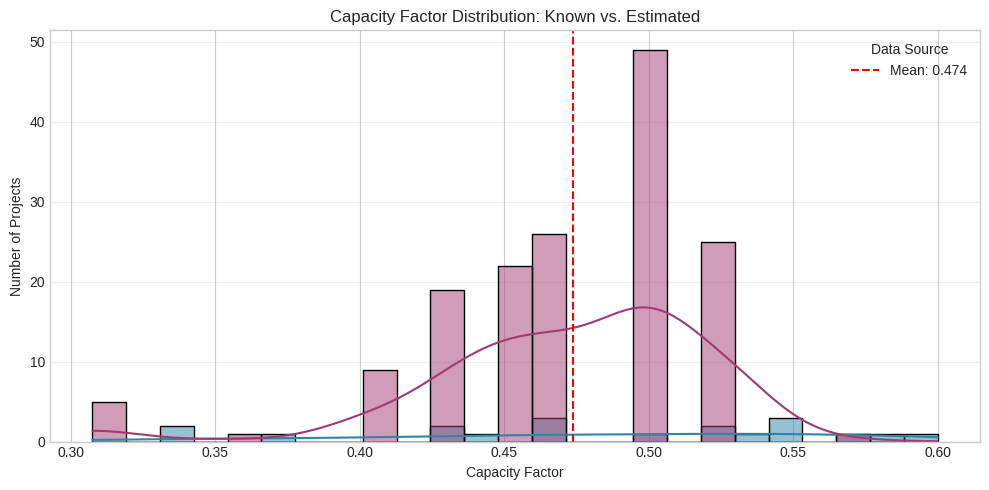

In [10]:
# ── Regression coefficients for CF estimation (projects ≥ 2010) ──
CF_SLOPE = 0.0960
CF_INTERCEPT = -0.4125

def estimate_capacity_factor(row):
    """
    Return known CF if available and valid; otherwise estimate from wind speed.
    Fallback to 0.40 if wind speed is also missing.
    """
    # Use known value if present and positive
    if pd.notna(row['capacity_factor']) and row['capacity_factor'] > 0:
        return row['capacity_factor']
    
    # Try to estimate from wind speed
    wind = row['mean_hub_wind_speed']
    if pd.isna(wind):
        return 0.40  # Conservative default fallback
    
    # Apply regression with bounds
    return np.clip(CF_SLOPE * wind + CF_INTERCEPT, 0.25, 0.65)


# ── Step 1: Estimate/fill capacity factor ──────────────────────────
df_model['capacity_factor_est'] = df_model.apply(estimate_capacity_factor, axis=1)

# Track source of CF value for later analysis
df_model['capacity_factor_source'] = df_model['capacity_factor'].apply(
    lambda x: 'Known' if pd.notna(x) else 'Estimated'
)


# ── Step 2: Calculate energy yield metrics ─────────────────────────
HOURS_PER_YEAR = 8760
AVAILABILITY_FACTOR = 0.85  # accounts for downtime + electrical losses

df_model['productivity_brutto_h'] = HOURS_PER_YEAR * df_model['capacity_factor_est']
df_model['productivity_netto_h'] = df_model['productivity_brutto_h'] * AVAILABILITY_FACTOR
df_model['annual_production_MWh'] = (
    df_model['productivity_netto_h'] * df_model['installed_capacity_MW']
)


# ── Step 3: Summary output ─────────────────────────────────────────
print("Energy Yield calculated")
print(f"   Mean Capacity Factor: {df_model['capacity_factor_est'].mean():.3f}")
print(f"   Mean Annual Production: {df_model['annual_production_MWh'].mean()/1e3:.0f} GWh/year")


# ── Step 4: Visualize CF distribution ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=df_model,
    x='capacity_factor_est',
    hue='capacity_factor_source',
    bins=25,
    kde=True,
    ax=ax,
    palette={'Known': '#2E86AB', 'Estimated': '#A23B72'}
)

ax.set_xlabel('Capacity Factor')
ax.set_ylabel('Number of Projects')
ax.set_title('Capacity Factor Distribution: Known vs. Estimated')
ax.axvline(
    df_model['capacity_factor_est'].mean(),
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f"Mean: {df_model['capacity_factor_est'].mean():.3f}"
)
ax.legend(title='Data Source')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
